# Taller 2: Preprocesamiento de datos

El conjunto de datos presentados a continuación contiene información de consumo relativa a los clientes de una empresa de telecomunicaciones. Se presenta:
*   Client_ID: identificador único del cliente.
*   Renta: renta básica del plan.
*   Uso_SMS: número de SMS enviados en el mes.
*   Deuda_Ant: deuda facturada en el mes anterior.
*   Min_callcenter: minutos de llamadas al centro de atención.
*   Antiguedad: antiguedad del cliente (en meses).
*   Uso_MB: total de MB consumidos en el periodo.
*   Deuda_Act: deuda facturada en el mes.
*   Uso_APP: MB consumidas en el APP de la operadora.
*   Min_Tot_3M: cantidad total de minutos de llamadas de los últimos 3meses.
*   Género: (M) para masculino, (F) para femenino.
*   Edad: edad (años cumplidos) del cliente.
*   NSE: nivel socioecónomico del cliente.
*   Estado civil: (S) soltero, (C) casado, (V) viudo.
*   Departamento: lugar de residencia declarada por el cliente.
*   Churn: (1) cliente fuga, (0) cliente no fuga

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder

import warnings
warnings.filterwarnings('ignore')

In [28]:
dataset_completo_url = 'Tablon_clientes.csv'
df = pd.read_csv(dataset_completo_url,
                 sep=';',
                 index_col=0)
print('El dataset tiene la forma {}.'.format(df.shape))

El dataset tiene la forma (4997, 15).


In [29]:
# Veamos los primeros 10 datos del dataset
df.head(10)

,GENERO,EDAD,NSE,ESTADOCIVIL,DEPARTAMENTO,RENTA,USO_SMS,DEUDA_ANT,MIN_CALLCENTER,ANTIGUEDAD,USO_MB,DEUDA_ACT,USO_APP,CHURN,MIN_TOT_3M
CLIENT_ID,,,,,,,,,,,,,,,
0,F,80,1,S,LIMA,49.047829,49.689196,50.259706,48.384797,70.0,49.034758,48.833764,NaN,0,100
1,M,26,1,C,LIMA,49.884485,49.126422,49.968794,51.132655,73.0,47.901566,48.864555,NaN,1,97
2,F,35,1,NaN,LIMA,49.674159,49.008166,48.994351,47.206821,69.0,50.561100,52.411366,NaN,1,98
3,M,30,1,V,LIMA,50.971497,NaN,50.074096,47.980931,69.0,49.279711,NaN,NaN,0,100
4,F,65,1,NaN,LIMA,52.313414,50.962695,49.619874,46.892785,49.0,51.430192,NaN,NaN,0,99
5,F,31,1,NaN,LIMA,48.337445,50.973634,49.687328,47.716027,69.0,48.796372,NaN,NaN,1,101
6,M,61,1,NaN,LIMA,52.132794,50.049151,50.088633,48.667979,70.0,48.910621,NaN,NaN,1,101
7,M,22,1,NaN,AREQUIPA,50.266767,49.798046,50.705168,50.727301,49.0,47.113836,NaN,NaN,1,102
8,M,56,1,NaN,AREQUIPA,51.894376,51.170047,50.961091,50.388492,69.0,48.808949,NaN,NaN,0,103


## Identificación de errores en el dataset

In [30]:
# Veamos las estadisticas de generales del dataset
# Tener en cuenta que object indica un tipo de dato genérico, que puede pensarse como un string, o una columna con diferentes tipos de datos
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4997 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   GENERO          4947 non-null   object 
 1   EDAD            4997 non-null   int64  
 2   NSE             4997 non-null   int64  
 3   ESTADOCIVIL     178 non-null    object 
 4   DEPARTAMENTO    4997 non-null   object 
 5   RENTA           4997 non-null   float64
 6   USO_SMS         4938 non-null   float64
 7   DEUDA_ANT       4967 non-null   float64
 8   MIN_CALLCENTER  4942 non-null   float64
 9   ANTIGUEDAD      4364 non-null   float64
 10  USO_MB          4997 non-null   float64
 11  DEUDA_ACT       4873 non-null   float64
 12  USO_APP         2404 non-null   float64
 13  CHURN           4997 non-null   int64  
 14  MIN_TOT_3M      4997 non-null   int64  
dtypes: float64(8), int64(4), object(3)
memory usage: 624.6+ KB


In [31]:
# Veamos los valores unicos en cada columna
df.nunique()

,0
GENERO,2
EDAD,55
NSE,1
ESTADOCIVIL,3
DEPARTAMENTO,15
RENTA,4996
USO_SMS,4938
DEUDA_ANT,4967
MIN_CALLCENTER,4942
ANTIGUEDAD,21


In [32]:
# La columna NSE solo presenta un valor: 1
# ¿Nos dice algo? ¿Qué acción tomamos?
df = df.drop(columns = 'NSE')

In [33]:
# Veamos los estadísticos descriptivos del dataset
df.describe()

,EDAD,RENTA,USO_SMS,DEUDA_ANT,MIN_CALLCENTER,ANTIGUEDAD,USO_MB,DEUDA_ACT,USO_APP,CHURN,MIN_TOT_3M
count,4997.000000,4997.000000,4938.000000,4967.000000,4942.000000,4364.000000,4997.000000,4873.000000,2404.000000,4997.000000,4997.000000
mean,40.367020,49.920460,49.996233,50.002322,49.648676,58.770852,49.664046,52.100426,50.934384,0.668001,99.329398
std,15.021341,4.162126,0.999000,1.003869,1.931749,9.666747,1.670653,147.138083,1.941698,0.470978,2.386067
min,5.000000,-140.000000,46.154745,46.433099,42.182816,30.000000,43.882448,46.710618,44.721870,0.000000,88.000000
25%,28.000000,48.787983,49.319983,49.336476,48.324646,50.000000,48.473757,49.298500,49.741090,0.000000,98.000000
50%,40.000000,49.948368,49.979600,50.015584,49.599311,53.000000,49.649429,50.008242,50.737098,1.000000,100.000000
75%,53.000000,51.147116,50.671762,50.688129,50.954613,69.000000,50.876590,50.670771,52.207674,1.000000,101.000000
max,130.000000,55.868670,53.895572,53.146460,56.371546,73.000000,55.867741,10321.000000,60.880871,1.000000,108.000000


In [34]:
# ¿Podemos tener clientes menores de edad?
# Reemplazamos los casos por un valor real
df.loc[df['EDAD']<18, 'EDAD'] = 18

In [35]:
# ¿Es creible que un cliente sea tan longevo?
# Eliminamos los valores de clientes cuya edad sea mayor a 80
ids = df.loc[df['EDAD']>80].index
df = df.drop(index=ids)

## Revisión de la distribución de variables
Podemos ver gráficamente la distribución de cada variable usando un histograma.<br>Importamos matplotlib, una librería para hacer gráficos en Python.

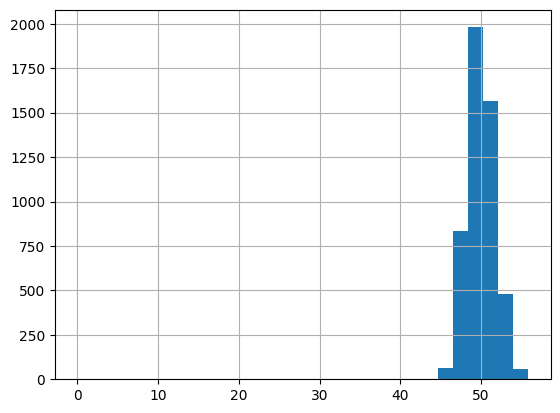

In [43]:
# Podemos ver gráficamente la distribución de cada variable usando un histograma
# Importamos matplotlib, una librería para hacer gráficos
df['RENTA'].hist(bins=30)
plt.show()

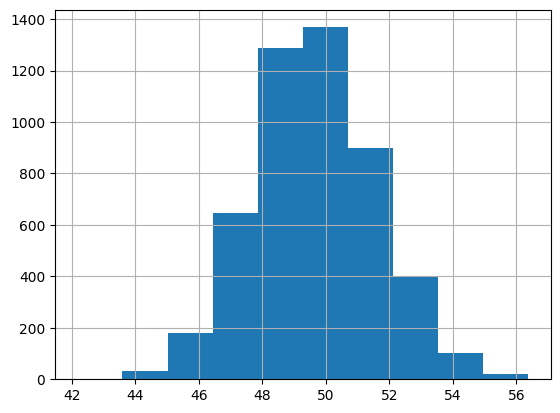

In [44]:
# Su respuesta aqui
df["MIN_CALLCENTER"].hist()
plt.show()

En este caso, se puede observar que la distribución es casi una normal.


Para las variables categóricas podemos ver los valores posibles que adoptan (categorías), así como su porcentaje.

In [47]:
df['ESTADOCIVIL'].value_counts(dropna=False)

,count
ESTADOCIVIL,
NaN,4814
C,144
S,26
V,8


In [48]:
# Veamos la cantidad de elementos por nivel de categoria
df['ESTADOCIVIL'].value_counts(dropna=False, normalize=True)

,proportion
ESTADOCIVIL,
NaN,0.964343
C,0.028846
S,0.005208
V,0.001603


## Imputación de valores perdidos
Es importante manejar los valores en blanco. Para ello, primero tenemos que identificarlos. La función isnull() nos facilita la tarea. Ella devuelve True para cuando algún campo de un registro es nulo.

In [51]:
df.head()

,GENERO,EDAD,ESTADOCIVIL,DEPARTAMENTO,RENTA,USO_SMS,DEUDA_ANT,MIN_CALLCENTER,ANTIGUEDAD,USO_MB,DEUDA_ACT,USO_APP,CHURN,MIN_TOT_3M
CLIENT_ID,,,,,,,,,,,,,,
0,F,80,S,LIMA,49.047829,49.689196,50.259706,48.384797,70.0,49.034758,48.833764,NaN,0,100
1,M,26,C,LIMA,49.884485,49.126422,49.968794,51.132655,73.0,47.901566,48.864555,NaN,1,97
2,F,35,NaN,LIMA,49.674159,49.008166,48.994351,47.206821,69.0,50.561100,52.411366,NaN,1,98
3,M,30,V,LIMA,50.971497,NaN,50.074096,47.980931,69.0,49.279711,NaN,NaN,0,100
4,F,65,NaN,LIMA,52.313414,50.962695,49.619874,46.892785,49.0,51.430192,NaN,NaN,0,99


In [52]:
df.isnull().head()

,GENERO,EDAD,ESTADOCIVIL,DEPARTAMENTO,RENTA,USO_SMS,DEUDA_ANT,MIN_CALLCENTER,ANTIGUEDAD,USO_MB,DEUDA_ACT,USO_APP,CHURN,MIN_TOT_3M
CLIENT_ID,,,,,,,,,,,,,,
0,False,False,False,False,False,False,False,False,False,False,False,True,False,False
1,False,False,False,False,False,False,False,False,False,False,False,True,False,False
2,False,False,True,False,False,False,False,False,False,False,False,True,False,False
3,False,False,False,False,False,True,False,False,False,False,True,True,False,False
4,False,False,True,False,False,False,False,False,False,False,True,True,False,False


Python interpreta el Falso como 0 y el Verdadero como 1. Por tanto, podemos sumar a nivel de columna para identificar la cantidad de nulos en cada una.

In [53]:
df.isnull().sum()

,0
GENERO,50
EDAD,0
ESTADOCIVIL,4814
DEPARTAMENTO,0
RENTA,0
USO_SMS,59
DEUDA_ANT,30
MIN_CALLCENTER,55
ANTIGUEDAD,633
USO_MB,0


De la misma manera, se puede identificar el porcentaje de vacios en cada variable.

In [54]:
df.isnull().sum() / df.shape[0]

,0
GENERO,0.010016
EDAD,0.000000
ESTADOCIVIL,0.964343
DEPARTAMENTO,0.000000
RENTA,0.000000
USO_SMS,0.011819
DEUDA_ANT,0.006010
MIN_CALLCENTER,0.011018
ANTIGUEDAD,0.126803
USO_MB,0.000000


Columnas que tienen un porcentaje muy alto de nulos, ¿valen conservarse?

In [55]:
df.drop(columns = ['ESTADOCIVIL'], inplace=True)

En algunos casos, podemos reemplazar los nulos por una constante. Por ejemplo, un nulo en USO_APP implica que el usuario no ha usado el APP.

In [56]:
df['USO_APP'] = df['USO_APP'].fillna(0)

En otros casos, podemos eliminar los registros que tengan en nulo dicho campo.
Hemos visto que el número de vacios en DEUDA_ANT es bajo. Podríamos proceder a eliminar los registros que tengan esa variable en nulo.

In [57]:
df.loc[df.DEUDA_ANT.isnull()].shape

(30, 13)

In [58]:
indices_eliminar = df.loc[df.DEUDA_ANT.isnull()].index
df.drop(indices_eliminar, inplace=True)

Y en otros casos, podemos reemplazar los nulos por una medida de tendencia central. Para sustentar ello, debemos revisar las distribuciones y asegurarnos de modificarla en la menor medida de lo posible. Por ejemplo, la variable ANTIGUEDAD.

In [60]:
df['ANTIGUEDAD'] = df['ANTIGUEDAD'].fillna(df['ANTIGUEDAD'].median())

Finalmente, para variables categóricas, podemos imputar con la moda o con una nueva categoria "No disponible".

In [61]:
df['GENERO'] = df['GENERO'].fillna('ND')

In [62]:
df.isnull().sum()

,0
GENERO,0
EDAD,0
DEPARTAMENTO,0
RENTA,0
USO_SMS,50
DEUDA_ANT,0
MIN_CALLCENTER,55
ANTIGUEDAD,0
USO_MB,0
DEUDA_ACT,124


### Ejercicios
Reemplace los vacíos en las columnas:
1.   MIN_CALLCENTER: con la media.
2.   USO_SMS: con cero (0)
3.   DEUDA_ACT: elimine todo registro que tenga nulo en dicho campo.

In [63]:
# Aquí su código


In [64]:
# Revisamos nuevamente si alguna variable queda con nulo
df.isnull().sum()

,0
GENERO,0
EDAD,0
DEPARTAMENTO,0
RENTA,0
USO_SMS,0
DEUDA_ANT,0
MIN_CALLCENTER,0
ANTIGUEDAD,0
USO_MB,0
DEUDA_ACT,0


## Busqueda de Outliers
Otro punto importante en el preprocesamiento es la deteccion y manejo de valores atípicos. La explicación del método de detección de los mismos escapa del alcance del curso, pero se deja una función que identifica los outliers en un dataframe para que pueda ser usado como caja negra.

In [65]:
def es_outlier(df, columna, umbral=1.5):
  q1 = df[columna].quantile(0.25)
  q3 = df[columna].quantile(0.75)
  iqr = q3 - q1
  return (df[columna]<q1-umbral*iqr)|(df[columna]>q3+umbral*iqr)

Ahora veamos cómo se emplea la función antes definida.

In [67]:
df.loc[es_outlier(df, 'DEUDA_ANT')].shape

(41, 13)

Por ejemplo, podemos ver que el dataframe contiene 41 outliers en la variable DEUDA_ANT. Para saber cuáles son, simplemente obtenemos sus índices:

In [68]:
df.loc[es_outlier(df, 'DEUDA_ANT')].index

Index([ 348,  354,  381,  387,  532,  536,  603,  800, 1004, 1190, 1212, 1216,
       1261, 1359, 1380, 1617, 1701, 1725, 1764, 1982, 2094, 2124, 2334, 2418,
       2568, 2840, 2916, 3122, 3169, 3187, 3355, 3496, 3748, 3805, 3968, 4099,
       4314, 4345, 4362, 4435, 4512],
      dtype='int64', name='CLIENT_ID')

De forma gráfica, se puede ver si una variable contiene outliers usando diagramas de caja (boxplots).

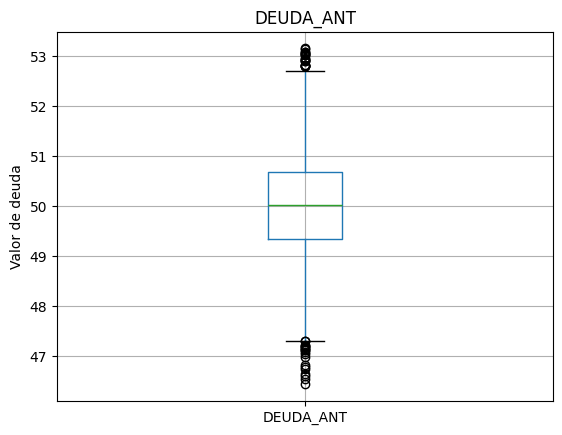

In [69]:
df.boxplot(column = ['DEUDA_ANT'])
plt.title('DEUDA_ANT')
plt.ylabel("Valor de deuda")
plt.show()

Los puntos fuera de la caja representan los outliers. Limpiemos la variable de outliers. Para ello, eliminaremos dichos registros.

In [70]:
indices_outliers = df.loc[es_outlier(df, 'DEUDA_ANT')].index
df.drop(index=indices_outliers, inplace=True)

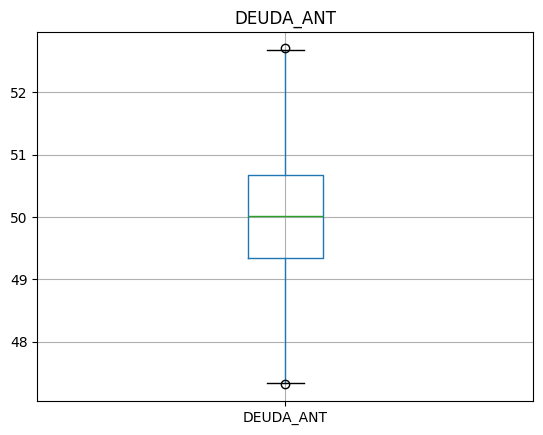

In [71]:
df.boxplot(column = ['DEUDA_ANT'])
plt.title('DEUDA_ANT')
plt.show()

Puede observarse que la mayoría de los outliers fueron limpiados. Se observa que han aparecido nuevos outliers debido al cambio que sufrió la distribución original al eliminar observaciones. En estos casos, puede optarse por mantenerlos o repetir el proceso para eliminarlos.

### Ejercicio
Procese los outliers de la variable USO_SMS. Solo elimine una vez los outliers. Dibuje el boxplot antes y después del proceso.

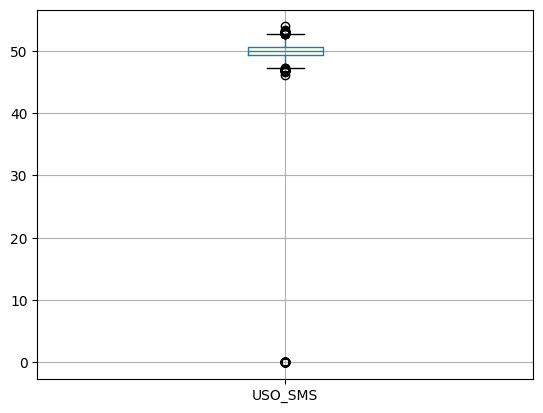

In [74]:
# Su respuesta aquí (boxplot inicial)


In [75]:
# Su respuesta aquí (procesar outliers)


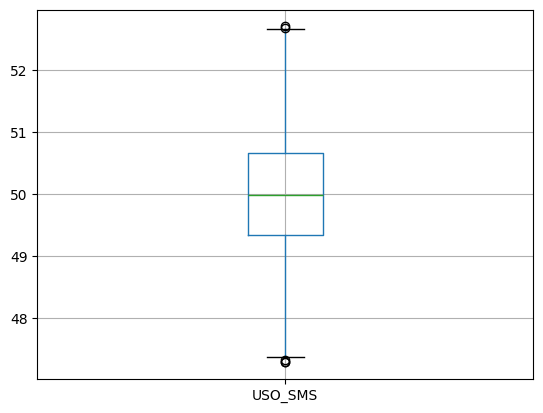

In [76]:
# Su respuesta aquí (boxplot final)


# Aprendizaje individual
Lea con atención la siguiente sección en casa.


## Escalando variables
Para algunos algoritmos, es importante llevar las variables a una misma escala. Para ello, se puede recurrir a la normalización y a la estandarización. <br>

### Normalizacion Min-Max
La normalización min-max lleva la variable a una escala de 0 a 1 y modifica la distribución de la variable.

In [77]:
# Escogemos las columnas a escalar (se excluyen algunas para trabajar otros conceptos)
columnas = ['MIN_TOT_3M', 'USO_SMS', 'MIN_CALLCENTER', 'ANTIGUEDAD', 'USO_APP', 'CHURN']

In [78]:
# Paso 1: se guarda el scaler en una variable
scaler_minmax = MinMaxScaler()
# Paso 2: se aplica el método fit del scaler sobre el conjunto de datos (con las columnas donde se va aplicar)
scaler_minmax.fit(df[columnas])
# Paso 3: se aplica el método transform del scaler sobre el conjunto de datos y se guarda el resultado.
df[columnas] = scaler_minmax.transform(df[columnas])

In [79]:
df.head()

,GENERO,EDAD,DEPARTAMENTO,RENTA,USO_SMS,DEUDA_ANT,MIN_CALLCENTER,ANTIGUEDAD,USO_MB,DEUDA_ACT,USO_APP,CHURN,MIN_TOT_3M
CLIENT_ID,,,,,,,,,,,,,
0,F,80,LIMA,49.047829,0.444266,50.259706,0.437106,0.930233,49.034758,48.833764,0.0,0.0,0.60
1,M,26,LIMA,49.884485,0.340369,49.968794,0.630771,1.000000,47.901566,48.864555,0.0,1.0,0.45
2,F,35,LIMA,49.674159,0.318537,48.994351,0.354084,0.906977,50.561100,52.411366,0.0,1.0,0.50
9,F,64,CUSCO,50.250351,0.558303,49.530684,0.378614,0.813953,52.072851,50.281705,0.0,1.0,0.55
11,F,22,PUNO,50.016053,0.447635,50.797049,0.605265,0.465116,53.408078,49.634421,0.0,0.0,0.55


## Encoding de variables categoricas

In [80]:
# Listamos variables categoricas
df.select_dtypes(['object','category']).columns

Index(['GENERO', 'DEPARTAMENTO'], dtype='object')

La variable GENERO tiene pocos valores. Podemos emplear una binarización

In [81]:
# Revisamos los posibles valores de GENERO
df.GENERO.value_counts()
df["GENERO"].value_counts()

,count
GENERO,
F,2332
M,2331
ND,49


In [82]:
# Binarizamos usando la función pd.get_dummies
df = pd.get_dummies(df, columns = ['GENERO'], drop_first=True)

In [83]:
df.head()

,EDAD,DEPARTAMENTO,RENTA,USO_SMS,DEUDA_ANT,MIN_CALLCENTER,ANTIGUEDAD,USO_MB,DEUDA_ACT,USO_APP,CHURN,MIN_TOT_3M,GENERO_M,GENERO_ND
CLIENT_ID,,,,,,,,,,,,,,
0,80,LIMA,49.047829,0.444266,50.259706,0.437106,0.930233,49.034758,48.833764,0.0,0.0,0.60,False,False
1,26,LIMA,49.884485,0.340369,49.968794,0.630771,1.000000,47.901566,48.864555,0.0,1.0,0.45,True,False
2,35,LIMA,49.674159,0.318537,48.994351,0.354084,0.906977,50.561100,52.411366,0.0,1.0,0.50,False,False
9,64,CUSCO,50.250351,0.558303,49.530684,0.378614,0.813953,52.072851,50.281705,0.0,1.0,0.55,False,False
11,22,PUNO,50.016053,0.447635,50.797049,0.605265,0.465116,53.408078,49.634421,0.0,0.0,0.55,False,False


Veamos como codificar la variable DEPARTAMENTO

In [84]:
# ¿Que valores tiene?
df['DEPARTAMENTO'].value_counts()

,count
DEPARTAMENTO,
LIMA,1078
PASCO,457
CUSCO,455
AREQUIPA,450
ICA,305
AYACUCHO,304
JUNIN,303
TACNA,300
PUNO,154


In [87]:
# Si bien el encoding se puede hacer manualmente, scikit-learn provee de un conjunto de Encoders que facilitan la tarea

# Paso 1: se guarda el encoder en una variable
label_encoder = LabelEncoder()
# Paso 2: se aplica el método fit del encoder sobre la columna a trabajar
label_encoder.fit(df['DEPARTAMENTO'])
# Paso 3: se aplica el método transform del encoder sobre la columna y se guarda el resultado
df['DEPARTAMENTO'] = label_encoder.transform(df['DEPARTAMENTO'])

In [88]:
df.head()

,EDAD,DEPARTAMENTO,RENTA,USO_SMS,DEUDA_ANT,MIN_CALLCENTER,ANTIGUEDAD,USO_MB,DEUDA_ACT,USO_APP,CHURN,MIN_TOT_3M,GENERO_M,GENERO_ND
CLIENT_ID,,,,,,,,,,,,,,
0,80,7,49.047829,0.444266,50.259706,0.437106,0.930233,49.034758,48.833764,0.0,0.0,0.60,False,False
1,26,7,49.884485,0.340369,49.968794,0.630771,1.000000,47.901566,48.864555,0.0,1.0,0.45,True,False
2,35,7,49.674159,0.318537,48.994351,0.354084,0.906977,50.561100,52.411366,0.0,1.0,0.50,False,False
9,64,3,50.250351,0.558303,49.530684,0.378614,0.813953,52.072851,50.281705,0.0,1.0,0.55,False,False
11,22,12,50.016053,0.447635,50.797049,0.605265,0.465116,53.408078,49.634421,0.0,0.0,0.55,False,False


Nota importante: en este caso, se ha aplicado el Label Encoder por motivos de presentar la librería scikit-learn. No obstante, no se recomienda usar esta técnica de encoding debido a que no hay una relación de orden entre los elementos, lo que puede llevar a resultados erróneos en algunos algoritmos de ML (como los que dependen de distancias).

## Guardar resultados
Una vez procesado el conjunto de datos, naturalmente querremos guardar los encoders, scalers y el tablón ya procesado.

In [91]:
# Podemos guardar los diccionarios de encoding para despues usando pickle
import pickle

with open('scaler_norm', 'wb') as file:
  pickle.dump(scaler_minmax, file)

with open('encoder_departamento', 'wb') as file:
  pickle.dump(label_encoder, file)

In [92]:
# Posteriormente, se puede cargar cada variable
import pickle

with open('encoder_departamento', 'rb') as file:
  my_enc_departamento = pickle.load(file)

with open('scaler_norm', 'rb') as file:
  scaler_norm = pickle.load(file)

In [93]:
# Podemos exportar el dataset limpio usando la funcion to_csv
df.to_csv('dataset_clean.csv', index = False, sep = ';')

Los archivos que aquí se generan pueden ser descargados de Google Collab para poder ser usados en cualquier otro momento.